Aperçu des données :


,Exam1,Exam2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1



Dimensions du dataset :
(100, 3)

Types des colonnes :
Exam1       float64
Exam2       float64
Admitted      int64
dtype: object

Statistiques descriptives :


,Exam1,Exam2,Admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000



Nombre d'étudiants admis et non admis :
Admitted
1    60
0    40
Name: count, dtype: int64


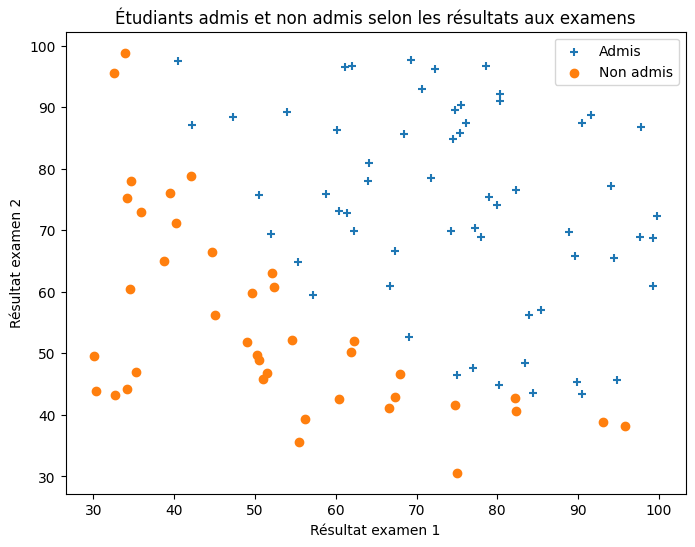

Taille de X_train : (80, 2)
Taille de X_test : (20, 2)
Taille de y_train : (80,)
Taille de y_test : (20,)
Modèle entraîné avec succès.
Précision du modèle : 0.95

Matrice de confusion :
[[ 8  0]
 [ 1 11]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      0.92      0.96        12

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



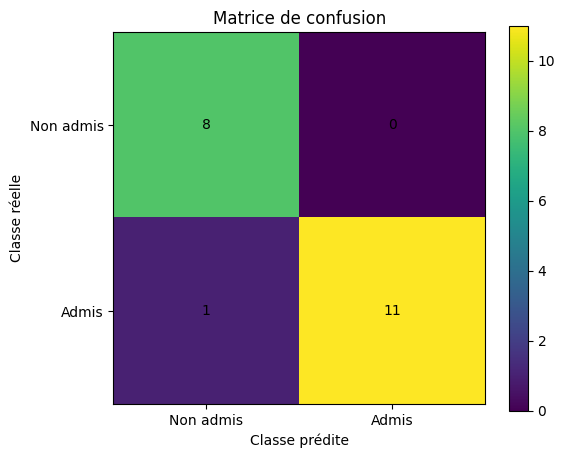

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


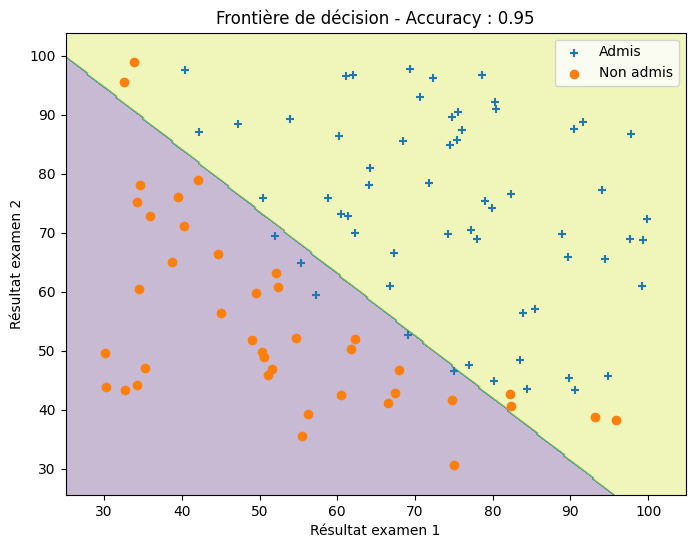


INTERPRÉTATION :

La régression logistique est adaptée à ce problème, car nous voulons prédire une variable binaire :
admis ou non admis.

Le modèle utilise les résultats aux deux examens pour estimer la probabilité qu’un étudiant soit admis.

La précision du modèle indique la proportion de bonnes prédictions sur les données de test.
Si la précision est élevée, cela signifie que le modèle distingue bien les étudiants admis des étudiants non admis.

La matrice de confusion permet de voir les bonnes et mauvaises prédictions :
- les vrais négatifs sont les étudiants non admis correctement prédits ;
- les vrais positifs sont les étudiants admis correctement prédits ;
- les faux positifs sont les étudiants prédits admis alors qu’ils ne le sont pas ;
- les faux négatifs sont les étudiants prédits non admis alors qu’ils sont admis.

La frontière de décision montre visuellement comment le modèle sépare les deux classes.
En général, les étudiants ayant de meilleurs résultats aux deux examens o

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




file_path = "/content/ex2data1.txt"

df = pd.read_csv(
    file_path,
    header=None,
    names=["Exam1", "Exam2", "Admitted"]
)

print("Aperçu des données :")
display(df.head())

print("\nDimensions du dataset :")
print(df.shape)

print("\nTypes des colonnes :")
print(df.dtypes)

print("\nStatistiques descriptives :")
display(df.describe())

print("\nNombre d'étudiants admis et non admis :")
print(df["Admitted"].value_counts())




admitted = df[df["Admitted"] == 1]
not_admitted = df[df["Admitted"] == 0]

plt.figure(figsize=(8, 6))

plt.scatter(
    admitted["Exam1"],
    admitted["Exam2"],
    marker="+",
    label="Admis"
)

plt.scatter(
    not_admitted["Exam1"],
    not_admitted["Exam2"],
    marker="o",
    label="Non admis"
)

plt.xlabel("Résultat examen 1")
plt.ylabel("Résultat examen 2")
plt.title("Étudiants admis et non admis selon les résultats aux examens")
plt.legend()
plt.show()



X = df[["Exam1", "Exam2"]]
y = df["Admitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille de X_train :", X_train.shape)
print("Taille de X_test :", X_test.shape)
print("Taille de y_train :", y_train.shape)
print("Taille de y_test :", y_test.shape)



scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




model = LogisticRegression()

model.fit(X_train_scaled, y_train)

print("Modèle entraîné avec succès.")



y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Précision du modèle :", round(accuracy, 4))


cm = confusion_matrix(y_test, y_pred)

print("\nMatrice de confusion :")
print(cm)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))



plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Matrice de confusion")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.colorbar()

classes = ["Non admis", "Admis"]

plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()



x_min, x_max = X["Exam1"].min() - 5, X["Exam1"].max() + 5
y_min, y_max = X["Exam2"].min() - 5, X["Exam2"].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

grid_scaled = scaler.transform(grid)

Z = model.predict(grid_scaled)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    admitted["Exam1"],
    admitted["Exam2"],
    marker="+",
    label="Admis"
)

plt.scatter(
    not_admitted["Exam1"],
    not_admitted["Exam2"],
    marker="o",
    label="Non admis"
)

plt.xlabel("Résultat examen 1")
plt.ylabel("Résultat examen 2")
plt.title(f"Frontière de décision - Accuracy : {accuracy:.2f}")
plt.legend()
plt.show()



print("""
INTERPRÉTATION :

La régression logistique est adaptée à ce problème, car nous voulons prédire une variable binaire :
admis ou non admis.

Le modèle utilise les résultats aux deux examens pour estimer la probabilité qu’un étudiant soit admis.

La précision du modèle indique la proportion de bonnes prédictions sur les données de test.
Si la précision est élevée, cela signifie que le modèle distingue bien les étudiants admis des étudiants non admis.

La matrice de confusion permet de voir les bonnes et mauvaises prédictions :
- les vrais négatifs sont les étudiants non admis correctement prédits ;
- les vrais positifs sont les étudiants admis correctement prédits ;
- les faux positifs sont les étudiants prédits admis alors qu’ils ne le sont pas ;
- les faux négatifs sont les étudiants prédits non admis alors qu’ils sont admis.

La frontière de décision montre visuellement comment le modèle sépare les deux classes.
En général, les étudiants ayant de meilleurs résultats aux deux examens ont plus de chances d’être admis.
""")